# Seaborn Plotting

This notebook demonstrates every seaborn plot type supported by `deckard.plot.seaborn_plots.SeabornPlotConfig` using synthetic datasets created with sklearn `make_*` helpers.

Each section renders the plot through deckard's wrapper and saves a PNG artifact under `notebooks/build/seaborn_artifacts`.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.datasets import (
    make_blobs,
    make_classification,
    make_friedman1,
    make_moons,
    make_regression,
)

from deckard.plugins.seaborn.plot import SeabornPlotConfig, supported_seaborn_plotters

SEED = 7
NOTEBOOK_ROOT = Path(".")
ARTIFACT_DIR = NOTEBOOK_ROOT / "build" / "seaborn"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def artifact_path(filename):
    return ARTIFACT_DIR / filename


print("Supported plot types:", supported_seaborn_plotters)
print("Artifacts will be written under:", ARTIFACT_DIR)

/opt/hostedtoolcache/Python/3.10.20/x64/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Supported plot types: ['scatter', 'line', 'hist', 'cat', 'bar', 'heatmap']
Artifacts will be written under: build/seaborn


In [2]:
classification_X, classification_y = make_classification(
    n_samples=160,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    n_classes=3,
    class_sep=1.5,
    random_state=SEED,
)
classification_df = pd.DataFrame(
    classification_X,
    columns=[f"feature_{i}" for i in range(classification_X.shape[1])],
)
classification_df["target"] = pd.Categorical(classification_y).rename_categories(
    ["class_0", "class_1", "class_2"]
)
classification_df["sample_index"] = np.arange(len(classification_df))

moons_X, moons_y = make_moons(n_samples=180, noise=0.18, random_state=SEED)
moons_df = pd.DataFrame(moons_X, columns=["feature_0", "feature_1"])
moons_df["target"] = pd.Categorical(moons_y).rename_categories(
    ["outer_arc", "inner_arc"]
)
moons_df["sample_index"] = np.arange(len(moons_df))

regression_X, regression_y = make_regression(
    n_samples=180,
    n_features=1,
    n_informative=1,
    noise=12.0,
    random_state=SEED,
)
regression_df = pd.DataFrame(
    {
        "feature_0": regression_X[:, 0],
        "target": regression_y,
    }
)
regression_df = regression_df.sort_values("feature_0").reset_index(drop=True)
regression_df["segment"] = pd.cut(
    regression_df["target"], bins=3, labels=["low", "mid", "high"]
)
regression_df["sample_index"] = np.arange(len(regression_df))

friedman_X, friedman_y = make_friedman1(
    n_samples=220, n_features=5, noise=1.0, random_state=SEED
)
friedman_df = pd.DataFrame(
    friedman_X, columns=[f"feature_{i}" for i in range(friedman_X.shape[1])]
)
friedman_df["target"] = friedman_y
friedman_df["band"] = pd.cut(
    friedman_df["target"], bins=4, labels=["q1", "q2", "q3", "q4"]
)

blobs_X, blobs_y = make_blobs(
    n_samples=200,
    centers=4,
    n_features=4,
    cluster_std=1.4,
    random_state=SEED,
)
blobs_df = pd.DataFrame(
    blobs_X, columns=[f"feature_{i}" for i in range(blobs_X.shape[1])]
)
blobs_df["cluster"] = pd.Categorical(blobs_y).rename_categories(
    ["cluster_0", "cluster_1", "cluster_2", "cluster_3"]
)

heatmap_df = (
    classification_df[["feature_0", "feature_1", "feature_2", "feature_3"]]
    .corr()
    .round(2)
)

dataset_summary = pd.DataFrame(
    [
        {
            "name": "classification",
            "shape": classification_df.shape,
            "purpose": "scatter, hist, bar",
        },
        {"name": "moons", "shape": moons_df.shape, "purpose": "cat"},
        {"name": "regression", "shape": regression_df.shape, "purpose": "line"},
        {"name": "friedman1", "shape": friedman_df.shape, "purpose": "hist"},
        {"name": "blobs", "shape": blobs_df.shape, "purpose": "bar aggregation"},
        {
            "name": "correlation matrix",
            "shape": heatmap_df.shape,
            "purpose": "heatmap",
        },
    ]
)

display(dataset_summary)

,name,shape,purpose
0,classification,"(160, 8)","scatter, hist, bar"
1,moons,"(180, 4)",cat
2,regression,"(180, 4)",line
3,friedman1,"(220, 7)",hist
4,blobs,"(200, 5)",bar aggregation
5,correlation matrix,"(4, 4)",heatmap


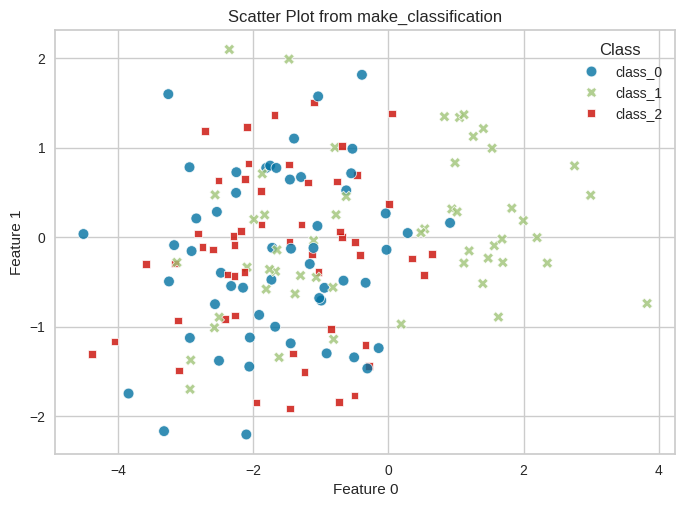

Saved: build/seaborn/scatter_scatter_plot_from_make_classification.png


In [3]:
def render_plot(title: str, **plot_kwargs):
    output_path = artifact_path(
        f"{plot_kwargs['plot_type']}_{title.lower().replace(' ', '_')}.png"
    )
    cfg = SeabornPlotConfig(
        plot_file=output_path.as_posix(),
        title=title,
        **plot_kwargs,
    )
    ax = cfg()
    display(ax.figure)
    plt.close(ax.figure)
    return output_path


scatter_path = render_plot(
    "Scatter Plot from make_classification",
    plot_type="scatter",
    data=classification_df,
    x="feature_0",
    y="feature_1",
    hue="target",
    style="target",
    xlabel="Feature 0",
    ylabel="Feature 1",
    legend_title="Class",
    kwargs={"s": 60, "alpha": 0.8},
)

print("Saved:", scatter_path)

## Line Plot

`make_regression` gives a smooth one-dimensional relationship that works well for `line` plots once sorted by the input feature.

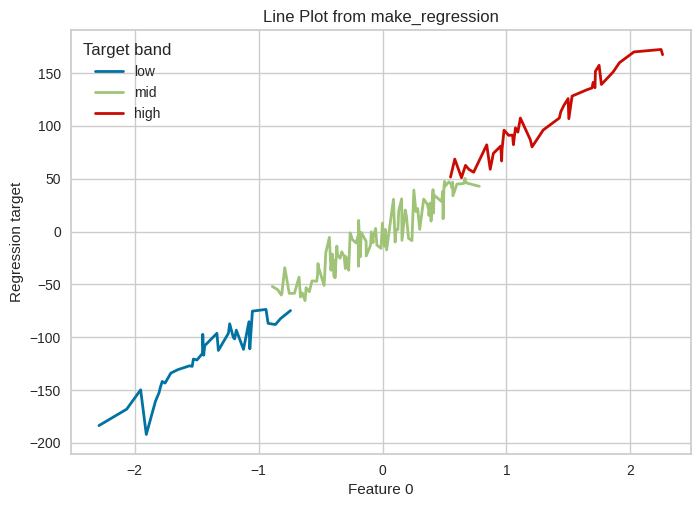

Saved: build/seaborn/line_line_plot_from_make_regression.png


In [4]:
line_path = render_plot(
    "Line Plot from make_regression",
    plot_type="line",
    data=regression_df,
    x="feature_0",
    y="target",
    hue="segment",
    xlabel="Feature 0",
    ylabel="Regression target",
    legend_title="Target band",
    kwargs={"linewidth": 2.0},
)

print("Saved:", line_path)

## Histogram Plot

`make_friedman1` produces a continuous target, which is useful for showing the distribution-focused `hist` API with hue buckets.

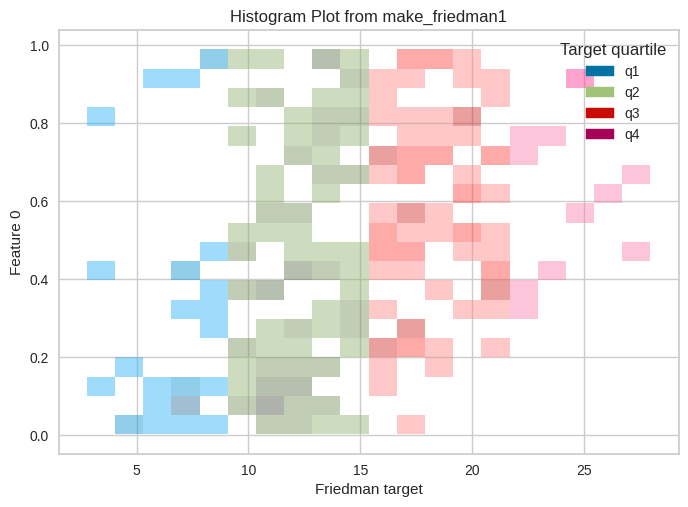

Saved: build/seaborn/hist_histogram_plot_from_make_friedman1.png


In [5]:
hist_path = render_plot(
    "Histogram Plot from make_friedman1",
    plot_type="hist",
    data=friedman_df,
    x="target",
    y="feature_0",
    hue="band",
    xlabel="Friedman target",
    ylabel="Feature 0",
    legend_title="Target quartile",
    kwargs={"bins": 20, "alpha": 0.45, "element": "step"},
)

print("Saved:", hist_path)

## Categorical Plot

`make_moons` creates a simple nonlinear classification problem. Here the wrapper uses `catplot` to compare one feature across the two moon labels.

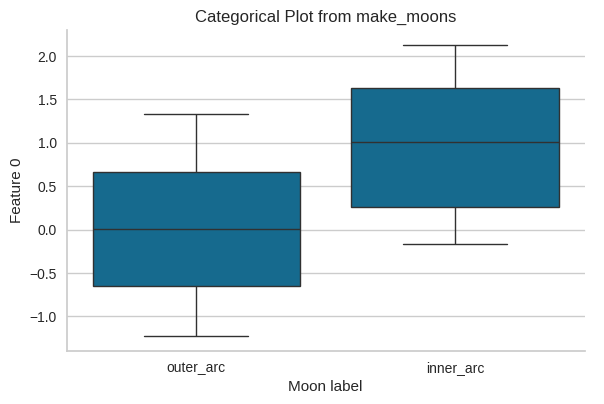

Saved: build/seaborn/cat_categorical_plot_from_make_moons.png


In [6]:
cat_path = render_plot(
    "Categorical Plot from make_moons",
    plot_type="cat",
    data=moons_df,
    x="target",
    y="feature_0",
    xlabel="Moon label",
    ylabel="Feature 0",
    kwargs={"kind": "box", "height": 4, "aspect": 1.5},
)

print("Saved:", cat_path)

## Bar Plot

`make_blobs` provides cluster labels that can be aggregated into per-cluster feature means for a straightforward `bar` example.

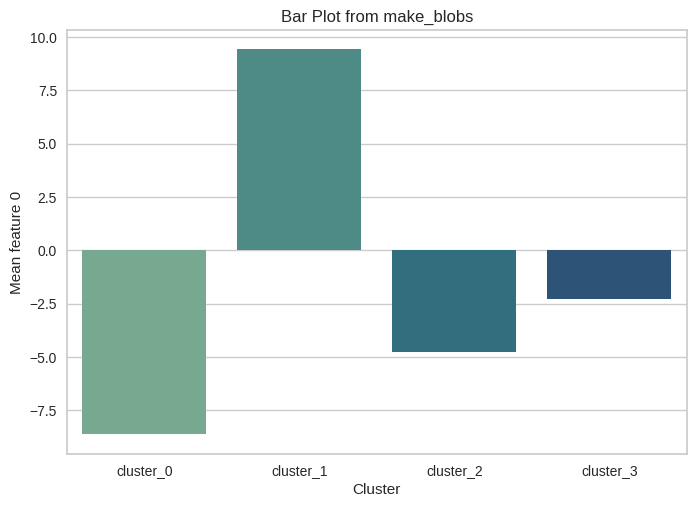

,cluster,mean_feature_0
0,cluster_0,-8.627061
1,cluster_1,9.419273
2,cluster_2,-4.763818
3,cluster_3,-2.266293


Saved: build/seaborn/bar_bar_plot_from_make_blobs.png


In [7]:
bar_df = (
    blobs_df.groupby("cluster", as_index=False)["feature_0"]
    .mean()
    .rename(columns={"feature_0": "mean_feature_0"})
)

bar_path = render_plot(
    "Bar Plot from make_blobs",
    plot_type="bar",
    data=bar_df,
    x="cluster",
    y="mean_feature_0",
    xlabel="Cluster",
    ylabel="Mean feature 0",
    kwargs={"palette": "crest"},
)

display(bar_df)
print("Saved:", bar_path)

## Heatmap

The heatmap example uses the correlation matrix from the classification dataset. This now exercises the dedicated heatmap argument handling in the wrapper.

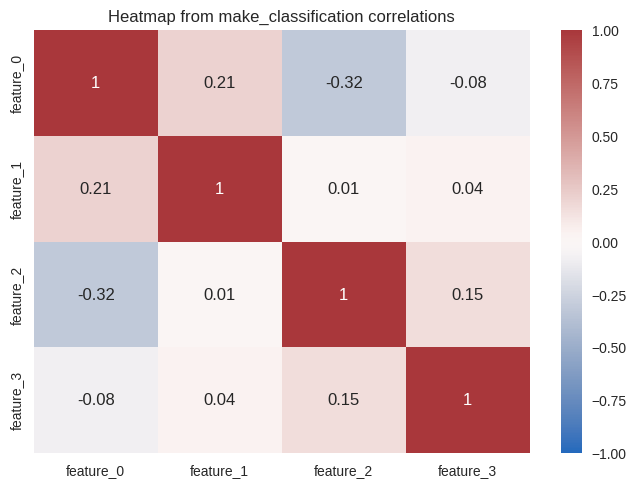

,feature_0,feature_1,feature_2,feature_3
feature_0,1.00,0.21,-0.32,-0.08
feature_1,0.21,1.00,0.01,0.04
feature_2,-0.32,0.01,1.00,0.15
feature_3,-0.08,0.04,0.15,1.00


Saved: build/seaborn/heatmap_heatmap_from_make_classification_correlations.png


In [8]:
heatmap_path = render_plot(
    "Heatmap from make_classification correlations",
    plot_type="heatmap",
    data=heatmap_df,
    x="feature_0",
    y="feature_1",
    kwargs={"annot": True, "cmap": "vlag", "vmin": -1.0, "vmax": 1.0},
)

display(heatmap_df)
print("Saved:", heatmap_path)

## Summary

All supported plot types are covered here through `SeabornPlotConfig`: `scatter`, `line`, `hist`, `cat`, `bar`, and `heatmap`.

In [9]:
summary_df = pd.DataFrame(
    [
        {
            "plot_type": "scatter",
            "dataset": "make_classification",
            "artifact": scatter_path.name,
        },
        {
            "plot_type": "line",
            "dataset": "make_regression",
            "artifact": line_path.name,
        },
        {"plot_type": "hist", "dataset": "make_friedman1", "artifact": hist_path.name},
        {"plot_type": "cat", "dataset": "make_moons", "artifact": cat_path.name},
        {"plot_type": "bar", "dataset": "make_blobs", "artifact": bar_path.name},
        {
            "plot_type": "heatmap",
            "dataset": "make_classification correlation",
            "artifact": heatmap_path.name,
        },
    ]
)

display(summary_df)

,plot_type,dataset,artifact
0,scatter,make_classification,scatter_scatter_plot_from_make_classification.png
1,line,make_regression,line_line_plot_from_make_regression.png
2,hist,make_friedman1,hist_histogram_plot_from_make_friedman1.png
3,cat,make_moons,cat_categorical_plot_from_make_moons.png
4,bar,make_blobs,bar_bar_plot_from_make_blobs.png
5,heatmap,make_classification correlation,heatmap_heatmap_from_make_classification_corre...


## Optional Dependencies

This notebook requires plotting dependencies for Seaborn workflows.

Recommended extras:

- `docs`
- `seaborn`

Install from repository root:

```bash
pip install -e '.[docs,seaborn]'
```

In [10]:
# Optional dependency installation (run only if your environment is missing packages)
# !pip install -e '../../.[docs,seaborn]'